# Эксперимент: сравнение моделей по метрикам

Этот ноутбук не обучает модели заново, а **сравнивает уже полученные артефакты**:
- `history_*.csv`
- `train_summary_*.json`
- сохранённые prediction examples

In [3]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = (PROJECT_ROOT / "..").resolve()

assert (PROJECT_ROOT / "src").exists(), f"Не найден src/ относительно {PROJECT_ROOT}"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)


PROJECT_ROOT = /home/jupyter/project


In [4]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

from src.utils.config import load_yaml


In [5]:
CONFIGS = {
    "UNet": PROJECT_ROOT / "configs" / "training_unet.yaml",
    "AttentionUNet": PROJECT_ROOT / "configs" / "training_attention_unet.yaml",
    "TransformerUNet": PROJECT_ROOT / "configs" / "training_transformer_unet.yaml",
}

rows = []
loaded = {}

for display_name, cfg_path in CONFIGS.items():
    if not cfg_path.exists():
        print(f"[SKIP] Не найден config: {cfg_path}")
        continue

    cfg = load_yaml(cfg_path)
    loaded[display_name] = cfg
    model_name = cfg["training"]["model_name"]
    artifacts_dir = PROJECT_ROOT / cfg["paths"].get("artifacts_dir", "artifacts")
    metrics_dir = artifacts_dir / "metrics"
    figures_dir = artifacts_dir / "figures"
    history_path = metrics_dir / f"history_{model_name}.csv"
    summary_path = metrics_dir / f"train_summary_{model_name}.json"

    history_df = pd.read_csv(history_path) if history_path.exists() else None
    summary = json.loads(summary_path.read_text(encoding="utf-8")) if summary_path.exists() else {}

    best_epoch = None
    best_val_dice = None
    best_val_iou = None
    last_val_dice = None
    epochs_completed = None

    if history_df is not None and not history_df.empty:
        idx = history_df["val_dice"].idxmax()
        best_epoch = int(history_df.loc[idx, "epoch"])
        best_val_dice = float(history_df.loc[idx, "val_dice"])
        best_val_iou = float(history_df.loc[idx, "val_iou"])
        last_val_dice = float(history_df.iloc[-1]["val_dice"])
        epochs_completed = int(history_df["epoch"].max())

    threshold_search = summary.get("threshold_search", {})
    selected_threshold = summary.get("selected_threshold", threshold_search.get("best_threshold"))

    rows.append(
        {
            "display_name": display_name,
            "model_name": model_name,
            "config_path": str(cfg_path.relative_to(PROJECT_ROOT)),
            "artifacts_dir": str(artifacts_dir.relative_to(PROJECT_ROOT)),
            "history_path": str(history_path.relative_to(PROJECT_ROOT)) if history_path.exists() else None,
            "summary_path": str(summary_path.relative_to(PROJECT_ROOT)) if summary_path.exists() else None,
            "best_epoch": best_epoch,
            "best_val_dice": best_val_dice,
            "best_val_iou": best_val_iou,
            "last_val_dice": last_val_dice,
            "epochs_completed": epochs_completed,
            "selected_threshold": selected_threshold,
        }
    )

comparison_df = pd.DataFrame(rows).sort_values("best_val_dice", ascending=False)
comparison_df


,display_name,model_name,config_path,artifacts_dir,history_path,summary_path,best_epoch,best_val_dice,best_val_iou,last_val_dice,epochs_completed,selected_threshold
2,TransformerUNet,transformer_unet,configs/training_transformer_unet.yaml,artifacts/transformer_unet_positive_tversky,artifacts/transformer_unet_positive_tversky/me...,artifacts/transformer_unet_positive_tversky/me...,31,0.573727,0.429766,0.563866,46,0.1
1,AttentionUNet,attention_unet,configs/training_attention_unet.yaml,artifacts/attention_unet_positive_tversky,artifacts/attention_unet_positive_tversky/metr...,artifacts/attention_unet_positive_tversky/metr...,45,0.509345,0.373842,0.503414,60,0.1
0,UNet,unet,configs/training_unet.yaml,artifacts/unet_positive_tversky,artifacts/unet_positive_tversky/metrics/histor...,artifacts/unet_positive_tversky/metrics/train_...,34,0.482280,0.345450,0.452704,49,0.1


In [6]:
if not comparison_df.empty:
    display_cols = [
        "display_name", "model_name", "best_epoch", "best_val_dice",
        "best_val_iou", "last_val_dice", "epochs_completed", "selected_threshold"
    ]
    comparison_df[display_cols]


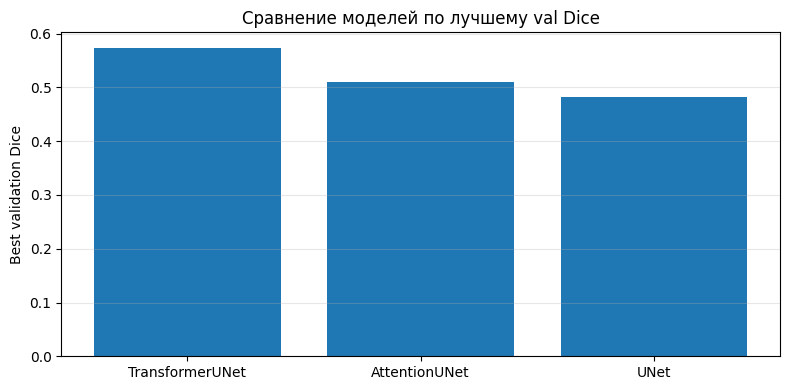

In [7]:
if not comparison_df.empty:
    plt.figure(figsize=(8, 4))
    plt.bar(comparison_df["display_name"], comparison_df["best_val_dice"])
    plt.ylabel("Best validation Dice")
    plt.title("Сравнение моделей по лучшему val Dice")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


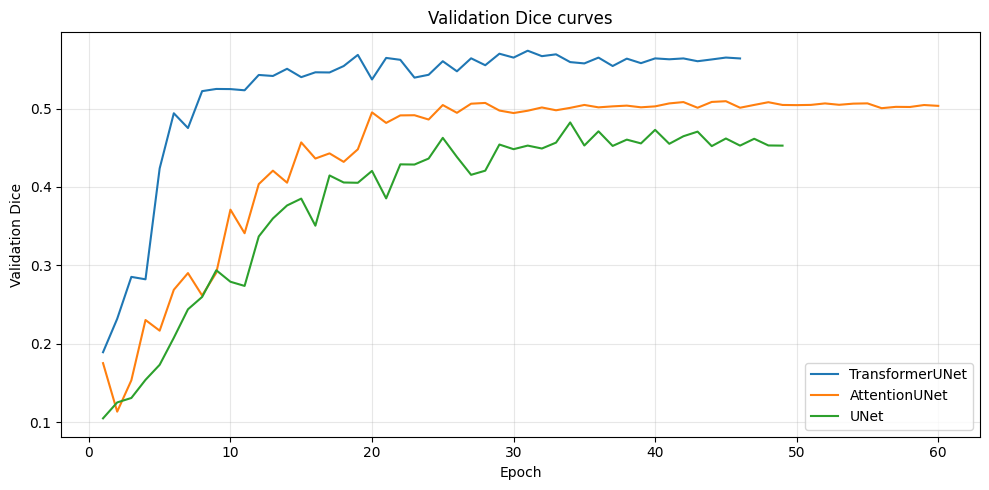

In [8]:
plt.figure(figsize=(10, 5))
for _, row in comparison_df.iterrows():
    history_path = PROJECT_ROOT / row["history_path"]
    if not history_path.exists():
        continue
    history_df = pd.read_csv(history_path)
    plt.plot(history_df["epoch"], history_df["val_dice"], label=row["display_name"])

plt.xlabel("Epoch")
plt.ylabel("Validation Dice")
plt.title("Validation Dice curves")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


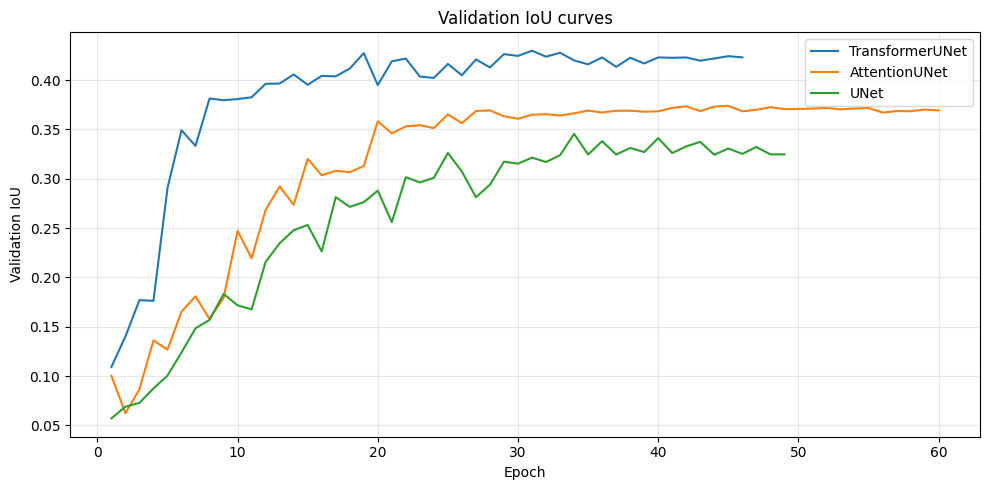

In [9]:
plt.figure(figsize=(10, 5))
for _, row in comparison_df.iterrows():
    history_path = PROJECT_ROOT / row["history_path"]
    if not history_path.exists():
        continue
    history_df = pd.read_csv(history_path)
    plt.plot(history_df["epoch"], history_df["val_iou"], label=row["display_name"])

plt.xlabel("Epoch")
plt.ylabel("Validation IoU")
plt.title("Validation IoU curves")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [10]:
pd.set_option("display.max_colwidth", None)
comparison_df[["display_name", "config_path", "history_path", "summary_path", "artifacts_dir"]]


,display_name,config_path,history_path,summary_path,artifacts_dir
2,TransformerUNet,configs/training_transformer_unet.yaml,artifacts/transformer_unet_positive_tversky/metrics/history_transformer_unet.csv,artifacts/transformer_unet_positive_tversky/metrics/train_summary_transformer_unet.json,artifacts/transformer_unet_positive_tversky
1,AttentionUNet,configs/training_attention_unet.yaml,artifacts/attention_unet_positive_tversky/metrics/history_attention_unet.csv,artifacts/attention_unet_positive_tversky/metrics/train_summary_attention_unet.json,artifacts/attention_unet_positive_tversky
0,UNet,configs/training_unet.yaml,artifacts/unet_positive_tversky/metrics/history_unet.csv,artifacts/unet_positive_tversky/metrics/train_summary_unet.json,artifacts/unet_positive_tversky


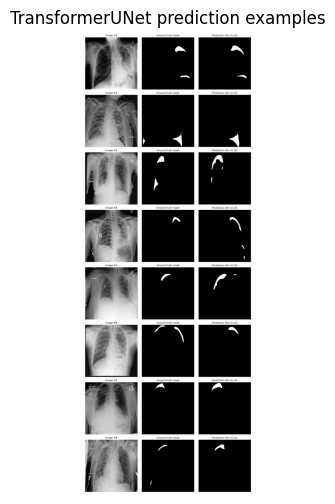

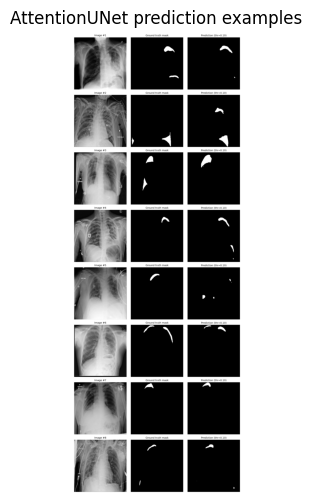

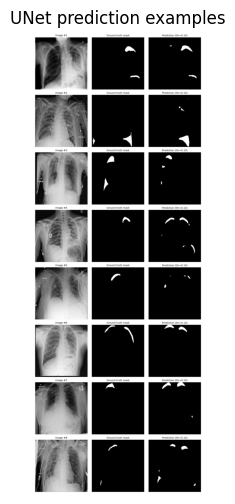

In [11]:
def show_prediction_figure(fig_path: Path, title: str):
    if not fig_path.exists():
        print(f"[MISS] {fig_path}")
        return
    img = Image.open(fig_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()

for _, row in comparison_df.iterrows():
    artifacts_dir = PROJECT_ROOT / row["artifacts_dir"]
    model_name = row["model_name"]
    candidate_paths = [
        artifacts_dir / "figures" / f"prediction_examples_{model_name}.png",
        artifacts_dir / "figures" / "prediction_examples_unet.png",
        artifacts_dir / "figures" / "example_prediction.png",
    ]
    found = next((p for p in candidate_paths if p.exists()), None)
    if found:
        show_prediction_figure(found, f"{row['display_name']} prediction examples")
    else:
        print(f"[MISS] Не найден prediction examples для {row['display_name']}")


In [12]:
if not comparison_df.empty:
    winner = comparison_df.iloc[0]
    print("Финальная модель по лучшему val Dice:")
    print(f"- display_name: {winner['display_name']}")
    print(f"- model_name  : {winner['model_name']}")
    print(f"- best_epoch  : {winner['best_epoch']}")
    print(f"- best_val_dice: {winner['best_val_dice']:.4f}")
    print(f"- best_val_iou : {winner['best_val_iou']:.4f}")
    print(f"- selected_threshold: {winner['selected_threshold']}")
    print(f"- config_path: {winner['config_path']}")


Финальная модель по лучшему val Dice:
- display_name: TransformerUNet
- model_name  : transformer_unet
- best_epoch  : 31
- best_val_dice: 0.5737
- best_val_iou : 0.4298
- selected_threshold: 0.1
- config_path: configs/training_transformer_unet.yaml
